# From dihedrals, reconstruct time evolution of the backbone


Side chains positions are missing, but at least we have something we can look at!

Output: 

- backbone_reconstruction.dcd
- backbone_reconstruction_first_frame.pdb

In [1]:
import numpy as np
import mdtraj as md
from tqdm import tqdm
import os

# Input directory
data_folder = "../data/"
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float) # degrees

# Output directory
output_directory = "../movies/"
os.makedirs(output_directory, exist_ok=True)

In [2]:
# ------------------------------------------------------------
# Geometry helpers
# ------------------------------------------------------------

def place_atom(a, b, c, length, angle_deg, dihedral_deg):
    """
    Place new atom d given previous atoms a,b,c.

    Geometry:
        |c-d| = length
        angle(b-c-d) = angle_deg
        dihedral(a-b-c-d) = dihedral_deg

    Coordinates in Å.
    """

    theta = np.deg2rad(angle_deg)
    phi = np.deg2rad(dihedral_deg)

    bc = c - b
    bc /= np.linalg.norm(bc)

    n = np.cross(b - a, bc)
    n /= np.linalg.norm(n)

    m = np.cross(n, bc)

    d = (
        c
        + length * (
            -np.cos(theta) * bc
            + np.sin(theta) * (np.cos(phi) * m + np.sin(phi) * n)
        )
    )

    return d


def place_oxygen(N, CA, C):
    """
    Approximate backbone carbonyl oxygen position.
    Uses fixed C=O bond length and approximate geometry.
    """

    # Approximate peptide geometry
    C_O = 1.229
    CA_C_O_angle = 120.8

    # Put oxygen roughly trans to N around the CA-C bond
    return place_atom(N, CA, C, C_O, CA_C_O_angle, 180.0)


# ------------------------------------------------------------
# Backbone reconstruction
# ------------------------------------------------------------

def reconstruct_backbone(phi, psi, omega=None, n_residues=35):
    """
    Reconstruct N, CA, C, O backbone atoms from torsions.

    Parameters
    ----------
    phi : array, shape (n_frames, n_residues-2)
        Phi angles in degrees for residues 2,...,n_residues-1.

    psi : array, shape (n_frames, n_residues-2)
        Psi angles in degrees for residues 2,...,n_residues-1.

    omega : array, optional
        Omega angles in degrees for residues 2,...,n_residues-1.
        If None, omega = 180 degrees.

    Returns
    -------
    xyz : array, shape (n_frames, n_residues*4, 3)
        Coordinates in Å.
        Atom order per residue: N, CA, C, O.
    """

    n_frames = phi.shape[0]

    if omega is None:
        omega = 180.0 * np.ones_like(phi)

    # Standard peptide geometry in Å and degrees
    N_CA = 1.458
    CA_C = 1.525
    C_N = 1.329

    C_N_CA = 121.7
    N_CA_C = 111.2
    CA_C_N = 116.2

    xyz = np.zeros((n_frames, n_residues * 4, 3))

    for t in tqdm(range(n_frames), desc="Reconstructing backbone"):

        atoms = []

        # ----------------------------------------------------
        # Initialize first residue in a fixed reference frame
        # ----------------------------------------------------

        N0 = np.array([0.0, 0.0, 0.0])
        CA0 = np.array([N_CA, 0.0, 0.0])

        angle = np.deg2rad(N_CA_C)
        C0 = CA0 + CA_C * np.array([
            np.cos(np.pi - angle),
            np.sin(np.pi - angle),
            0.0
        ])

        O0 = place_oxygen(N0, CA0, C0)

        atoms.extend([N0, CA0, C0, O0])

        N_prev = N0
        CA_prev = CA0
        C_prev = C0

        # ----------------------------------------------------
        # Build residues 2,...,n_residues
        # ----------------------------------------------------

        for i in range(1, n_residues):

            # Map residue index to torsion column.
            #
            # Your arrays contain residues 2,...,34 only.
            # Python residue index:
            #   i = 0 -> residue 1
            #   i = 1 -> residue 2
            #   ...
            #   i = 33 -> residue 34
            #   i = 34 -> residue 35
            #
            # column = i - 1 for residues 2,...,34.

            if 1 <= i <= n_residues - 2:
                col = i - 1
                phi_i = phi[t, col]
                psi_prev = psi[t, col - 1] if col > 0 else 180.0
                omega_prev = omega[t, col - 1] if col > 0 else 180.0
            else:
                phi_i = 180.0
                psi_prev = psi[t, -1] if i == n_residues - 1 else 180.0
                omega_prev = omega[t, -1] if i == n_residues - 1 else 180.0

            # New N_i from psi_{i-1}
            N_i = place_atom(
                N_prev, CA_prev, C_prev,
                length=C_N,
                angle_deg=CA_C_N,
                dihedral_deg=psi_prev
            )

            # New CA_i from omega_{i-1}
            CA_i = place_atom(
                CA_prev, C_prev, N_i,
                length=N_CA,
                angle_deg=C_N_CA,
                dihedral_deg=omega_prev
            )

            # New C_i from phi_i
            C_i = place_atom(
                C_prev, N_i, CA_i,
                length=CA_C,
                angle_deg=N_CA_C,
                dihedral_deg=phi_i
            )

            O_i = place_oxygen(N_i, CA_i, C_i)

            atoms.extend([N_i, CA_i, C_i, O_i])

            N_prev, CA_prev, C_prev = N_i, CA_i, C_i

        xyz[t] = np.array(atoms)

    return xyz

# -------------------------------------------------------------
# Create topology for the reconstructed backbone
#-------------------------------------------------------------

topology = md.Topology()
chain = topology.add_chain()

for i in range(35):
    residue = topology.add_residue(f"RES{i+1}", chain)

    N = topology.add_atom("N", md.element.nitrogen, residue)
    CA = topology.add_atom("CA", md.element.carbon, residue)
    C = topology.add_atom("C", md.element.carbon, residue)
    O = topology.add_atom("O", md.element.oxygen, residue)

    topology.add_bond(N, CA)
    topology.add_bond(CA, C)
    topology.add_bond(C, O)

    if i > 0:
        prev_C = list(topology.residue(i-1).atoms)[2]
        topology.add_bond(prev_C, N)

---
## Option A: whole trajectory, with custom stride

Load dihedrals trajectory data

In [53]:
# For testing, reconstruct only a few frames first
stride = 100
run_bool = False

if run_bool:
    job_name = f"stride_{stride}"
    job_folder = output_directory + job_name + "/"
    os.makedirs(job_folder, exist_ok=True)


    dihedral_movie = dihedral_timeseries[::stride] # subsample


    phi_series = dihedral_movie[:, 0::2] # phi angles are in the even columns
    psi_series = dihedral_movie[:, 1::2]
    omega_series = 180.0 * np.ones_like(phi_series)


    xyz_angstrom = reconstruct_backbone(
        phi_series,
        psi_series,
        omega_series,
        n_residues=35
    )

    traj = md.Trajectory(
        xyz=xyz_angstrom / 10.0,  # Å -> nm
        topology=topology
    )


    # Kabsch alignment
    ref = traj[0]
    ca_indices = traj.topology.select("name CA")
    traj.superpose(ref, atom_indices=ca_indices)

    traj.save_pdb(job_folder + "first_frame.pdb")
    traj.save_dcd(job_folder + "traj.dcd")

---

# Option B: selected frames only

In [5]:
stride = 1 #00000 # msm resolution
filename = "tica_distances_3state_macro2_frames"


# Load frames indexes from the MSM analysis
filepath = "../intermediate_outputs/frame_lists/"
frame_idxs = np.load(filepath + f"{filename}.npy")


job_name = f"{filename}_stride_{stride}"


run_bool = True

if run_bool:

    job_folder = output_directory + job_name + "/"
    os.makedirs(job_folder, exist_ok=True)


    dihedral_movie = dihedral_timeseries[frame_idxs] # subsample


    phi_series = dihedral_movie[:, 0::2] # phi angles are in the even columns
    psi_series = dihedral_movie[:, 1::2]
    omega_series = 180.0 * np.ones_like(phi_series)


    xyz_angstrom = reconstruct_backbone(
        phi_series,
        psi_series,
        omega_series,
        n_residues=35
    )

    traj = md.Trajectory(
        xyz=xyz_angstrom / 10.0,  # Å -> nm
        topology=topology
    )


    # Kabsch alignment
    ref = traj[0]
    ca_indices = traj.topology.select("name CA")
    traj.superpose(ref, atom_indices=ca_indices)

    traj.save_pdb(job_folder + "first_frame.pdb")
    traj.save_dcd(job_folder + "traj.dcd")

Reconstructing backbone: 100%|██████████| 13/13 [00:00<00:00, 119.23it/s]


---
# Option C: single folding event

In [3]:
total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


number of frames in the RMSD plot: 250.14999999998577
number of MSM steps: 0.2499999999999858


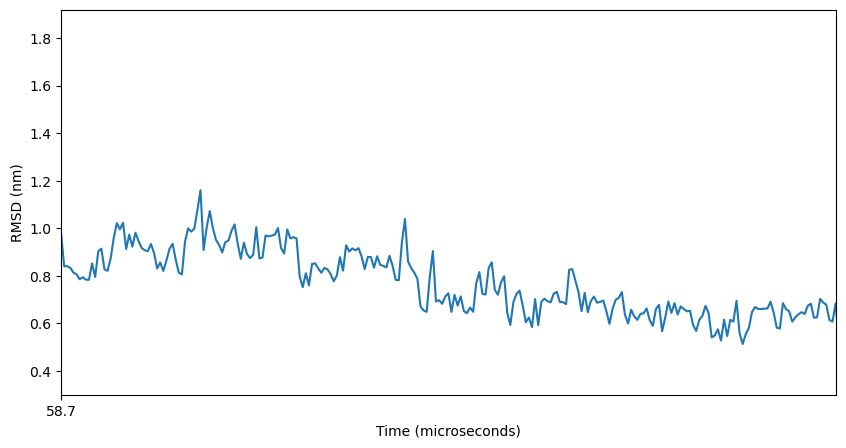

In [4]:
tmin = 58.7
tmax = 58.75

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(rmsd)
plt.xticks(np.arange(one_microsecond_in_frames*tmin, one_microsecond_in_frames*tmax, one_microsecond_in_frames), np.arange(tmin, tmax))
plt.xlabel("Time (microseconds)")
plt.ylabel("RMSD (nm)")
plt.xlim(one_microsecond_in_frames * tmin, one_microsecond_in_frames * tmax)

print("number of frames in the RMSD plot:", one_microsecond_in_frames * (tmax - tmin))

MSM_LAG = 0.200 #mus
print("number of MSM steps:", (tmax - tmin) / MSM_LAG)


frame_idxs = np.arange(int(one_microsecond_in_frames*tmin), int(one_microsecond_in_frames*tmax))

In [5]:
## --- Relevant dihedrals for the folding event
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float)
phis_timeseries = dihedral_timeseries[frame_idxs, 0::2] # degrees
psis_timeseries = dihedral_timeseries[frame_idxs, 1::2] # degrees
print(phis_timeseries.shape)

(250, 33)


Text(0, 0.5, 'Phi angles (degrees)')

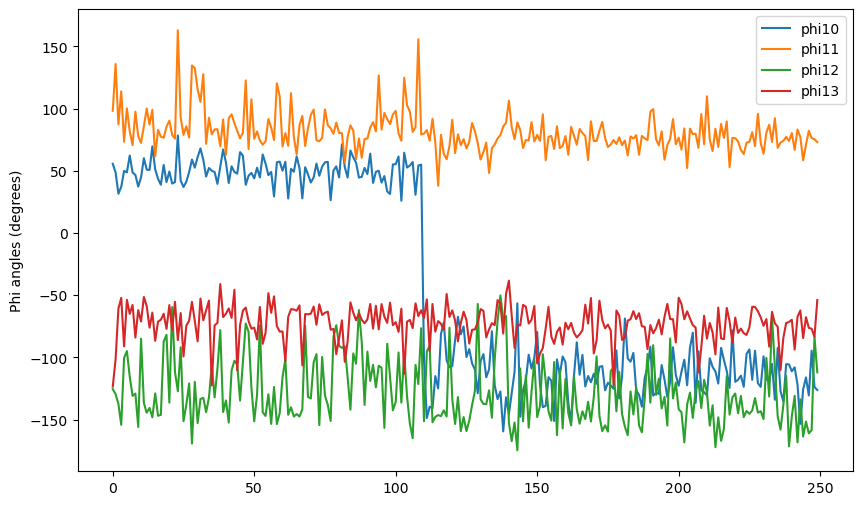

In [9]:
res_start = 10
res_end = 14


fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
for i in range(res_start, res_end):
    ax.plot(phis_timeseries[:, i-2], label=f"phi{i}") # col zero = res 2
    

ax.legend()
ax.set_ylabel("Phi angles (degrees)")

In [ ]:

filename = "single_folding_event"


# Load frames indexes from the MSM analysis
#filepath = "../intermediate_outputs/frame_lists/"
#frame_idxs = np.load(filepath + f"{filename}.npy")


job_name = f"{filename}"


run_bool = True

if run_bool:

    job_folder = output_directory + job_name + "/"
    os.makedirs(job_folder, exist_ok=True)


    dihedral_movie = dihedral_timeseries[frame_idxs] # subsample


    phi_series = dihedral_movie[:, 0::2] # phi angles are in the even columns
    psi_series = dihedral_movie[:, 1::2]
    omega_series = 180.0 * np.ones_like(phi_series)


    xyz_angstrom = reconstruct_backbone(
        phi_series,
        psi_series,
        omega_series,
        n_residues=35
    )

    traj = md.Trajectory(
        xyz=xyz_angstrom / 10.0,  # Å -> nm
        topology=topology
    )


    # Kabsch alignment
    ref = traj[0]
    ca_indices = traj.topology.select("name CA")
    traj.superpose(ref, atom_indices=ca_indices)

    traj.save_pdb(job_folder + "first_frame.pdb")
    traj.save_dcd(job_folder + "traj.dcd")

Reconstructing backbone:   0%|          | 0/250 [00:00<?, ?it/s]

Reconstructing backbone: 100%|██████████| 250/250 [00:01<00:00, 187.60it/s]
